# Goal
We want to build a model that can simply reverse sort a list of input numbers. 

e.g. prompt `[0,2,1]` the model can output `[2,1,0]`

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt
import copy

## Rewards
we'll first show 10 examples that we'll use to see how well each reward function works

In [2]:
torch.manual_seed(14)
ten_examples = torch.randint(0, 4, (10, 2, 4))

In [3]:
def apply_reward(reward_func):
    for i, (p, r) in enumerate(ten_examples):
        reward = reward_func(p,r)
        print(f'index {i} |reward {reward}| prompt {p.tolist()} | response{r.tolist()}')

### Distance reward

calculates reward based on how many positions in output match up with true sort

In [4]:
def sort_distance_reward(prompt, response):
    assert len(prompt) == len(response)
    ground_truth = sorted(prompt, reverse=True)
    match = sum(1 for x,y in zip(response, ground_truth) if x == y)
    return match

In [5]:
apply_reward(sort_distance_reward)

index 0 |reward 1| prompt [3, 0, 0, 2] | response[3, 1, 2, 2]
index 1 |reward 1| prompt [0, 2, 0, 1] | response[0, 1, 2, 1]
index 2 |reward 1| prompt [3, 2, 3, 0] | response[3, 0, 1, 2]
index 3 |reward 1| prompt [2, 0, 2, 0] | response[1, 1, 0, 1]
index 4 |reward 2| prompt [1, 0, 3, 3] | response[3, 0, 1, 1]
index 5 |reward 0| prompt [3, 0, 1, 3] | response[2, 0, 3, 1]
index 6 |reward 3| prompt [3, 3, 1, 2] | response[3, 2, 2, 1]
index 7 |reward 0| prompt [0, 3, 0, 3] | response[2, 1, 3, 2]
index 8 |reward 2| prompt [3, 1, 1, 3] | response[1, 1, 1, 1]
index 9 |reward 0| prompt [0, 3, 1, 3] | response[1, 1, 3, 1]


## Sort Inclusion reward
1 point for getting the right numbers; 1 point for the the right ordering where adjacencies decrease

In [6]:
def sort_inclusion_ordering_reward(prompt, response):
    assert len(prompt) == len(response)
    inclusion_reward = sum(1 for x in prompt if x in response)
    order_reward = sum(1 for x,y in zip(response[:-1],response[1:]) if x > y)
    return inclusion_reward + order_reward

In [7]:
apply_reward(sort_inclusion_ordering_reward)

index 0 |reward 3| prompt [3, 0, 0, 2] | response[3, 1, 2, 2]
index 1 |reward 5| prompt [0, 2, 0, 1] | response[0, 1, 2, 1]
index 2 |reward 5| prompt [3, 2, 3, 0] | response[3, 0, 1, 2]
index 3 |reward 3| prompt [2, 0, 2, 0] | response[1, 1, 0, 1]
index 4 |reward 5| prompt [1, 0, 3, 3] | response[3, 0, 1, 1]
index 5 |reward 6| prompt [3, 0, 1, 3] | response[2, 0, 3, 1]
index 6 |reward 6| prompt [3, 3, 1, 2] | response[3, 2, 2, 1]
index 7 |reward 4| prompt [0, 3, 0, 3] | response[2, 1, 3, 2]
index 8 |reward 2| prompt [3, 1, 1, 3] | response[1, 1, 1, 1]
index 9 |reward 4| prompt [0, 3, 1, 3] | response[1, 1, 3, 1]


## Customized reward
1 point for getting the right numbers; -1 point for including an errored number;
1 port for the right ordering where adjacenties decrease or are the same since we allow duplicates

In [8]:
def sort_complex_reward(prompt, response):
    assert len(prompt) == len(response)
    inclusion_reward = sum(1 for x in prompt if x in response)
    exclusion_penalty = sum(-1 for x in response if x not in prompt)
    order_reward = sum(1 for x,y in zip(response[:-1],response[1:]) if x >= y)
    return inclusion_reward + exclusion_penalty + order_reward

In [9]:
apply_reward(sort_complex_reward)

index 0 |reward 3| prompt [3, 0, 0, 2] | response[3, 1, 2, 2]
index 1 |reward 5| prompt [0, 2, 0, 1] | response[0, 1, 2, 1]
index 2 |reward 4| prompt [3, 2, 3, 0] | response[3, 0, 1, 2]
index 3 |reward 1| prompt [2, 0, 2, 0] | response[1, 1, 0, 1]
index 4 |reward 6| prompt [1, 0, 3, 3] | response[3, 0, 1, 1]
index 5 |reward 5| prompt [3, 0, 1, 3] | response[2, 0, 3, 1]
index 6 |reward 7| prompt [3, 3, 1, 2] | response[3, 2, 2, 1]
index 7 |reward 1| prompt [0, 3, 0, 3] | response[2, 1, 3, 2]
index 8 |reward 5| prompt [3, 1, 1, 3] | response[1, 1, 1, 1]
index 9 |reward 5| prompt [0, 3, 1, 3] | response[1, 1, 3, 1]


## Policy / Model 
Simple model to take prompt and define response,  the goal of this is to have it reverse the order


In [10]:
class Model(nn.Module):
    def __init__(self, vocab_size, embd_dim, prompt_len, response_len):
        super().__init__()
        self.response_len = response_len
        
        self.embedding = nn.Embedding(vocab_size, embd_dim)
        self.prompt_pos_embedding = nn.Embedding(prompt_len, embd_dim)
        self.response_pos_embedding = nn.Embedding(response_len, embd_dim)
        self.encoder = nn.Linear(embd_dim, embd_dim)
        self.decoder = nn.Linear(embd_dim, embd_dim)
        self.output = nn.Linear(embd_dim, vocab_size)
        
    def forward(self, prompts):
        batch_size, prompt_len = prompts.shape
        
        # generate positions representations for input and output
        prompt_positions = torch.arange(prompt_len)
        response_positions = torch.arange(self.response_len)

        embeddings = self.embedding(prompts)
        embeddings =  embeddings + self.prompt_pos_embedding(prompt_positions)            
        encoded = self.encoder(embeddings).sum(dim=1)

        resp_position_embed = self.response_pos_embedding(response_positions).unsqueeze(0)
        decoded = self.decoder(encoded).unsqueeze(1)  
        decoded = decoded + resp_position_embed
        logits = self.output(decoded)
        return logits


## Generate responses from model

In [11]:
def generate_responses(prompts, model, num_responses=1):
    logits = model(prompts)
    batch_size = prompts.shape[0]

    logits = logits.reshape(-1, logits.size(-1))
    probs = torch.softmax(logits, dim=-1)
    
    # sample from logits to get responses
    responses = torch.multinomial(probs, num_responses, replacement=True)
    responses = responses.reshape(batch_size, -1, num_responses).permute(0, 2, 1)

    return responses

In [12]:
vocab_size = 5
embedding_dim = 8
prompt_length = 4
response_length = 4

In [13]:
model = Model(
    vocab_size = vocab_size,
    embd_dim = embedding_dim , 
    prompt_len = prompt_length, 
    response_len = response_length
)

In [14]:
torch.manual_seed(14)
prom = torch.tensor([[3,0,1,2]])
resp = generate_responses(prom, model, 10)
resp.shape, resp

(torch.Size([1, 10, 4]),
 tensor([[[2, 3, 4, 4],
          [2, 4, 4, 4],
          [2, 3, 4, 4],
          [2, 0, 4, 4],
          [1, 2, 1, 0],
          [1, 1, 4, 4],
          [4, 4, 4, 2],
          [4, 1, 4, 2],
          [1, 4, 4, 4],
          [1, 4, 4, 4]]]))

## Compute reward

In [15]:
def compute_reward(prompts, responses, reward_fn):
    batch, n_resp, _ = responses.shape
    rewards = torch.empty(batch, n_resp, dtype=torch.float32)
    for i in range(batch):
        for j in range(n_resp):
            rewards[i,j] = reward_fn(prompts[i,:], responses[i,j,:])
            #print(rewards[i,j])
    return rewards

In [16]:
rew = compute_reward(prom, resp, sort_complex_reward)
rew

tensor([[1., 0., 1., 2., 5., 1., 1., 2., 0., 0.]])

## Compute $\delta$ for reward R

In [17]:
def compute_deltas(rewards, mode):
    if mode == 'rewards':
        return rewards

    if mode == 'centered':
        mean_rewards = rewards.mean(dim=-1, keepdim=True)
        centered_rewards = rewards - mean_rewards
        return centered_rewards

    if mode == 'normalized':
        mean_rewards = rewards.mean(dim=-1, keepdim=True)
        std_rewards = rewards.std(dim=-1, keepdim=True)
        centered_rewards = rewards - mean_rewards
        normalized_rewards = centered_rewards / (std_rewards + 1e-5)
        return normalized_rewards

    if mode == 'max_min':
        max_reward = rewards.max(dim=-1, keepdim=True)[0]
        min_reward = rewards.min(dim=-1, keepdim=True)[0]

        is_max = rewards == max_reward
        is_min_neg = (rewards == min_reward) & (min_reward < 0)
        mask = is_max | is_min_neg
        max_min_reward = torch.where(mask, rewards, torch.zeros_like(rewards))
        
        return max_min_reward
    

In [18]:
delta = compute_deltas(rew, 'normalized')
delta

tensor([[-0.2007, -0.8699, -0.2007,  0.4684,  2.4758, -0.2007, -0.2007,  0.4684,
         -0.8699, -0.8699]])

## Compute logprobs

In [19]:
def compute_log_probs(prompts, responses, model):
    logits = model(prompts)
    log_probs = F.log_softmax(logits, dim=-1).unsqueeze(1)
    log_probs = log_probs.expand(-1, responses.size(1), -1, -1)
    log_probs = log_probs.gather(dim=-1, index=responses.unsqueeze(-1)).squeeze(-1)
    return log_probs

In [20]:
logprobs = compute_log_probs(prom, resp, model)
logprobs

tensor([[[-1.3526, -2.9287, -0.5651, -0.8208],
         [-1.3526, -1.1306, -0.5651, -0.8208],
         [-1.3526, -2.9287, -0.5651, -0.8208],
         [-1.3526, -2.1850, -0.5651, -0.8208],
         [-1.1877, -1.8605, -1.9184, -2.4133],
         [-1.1877, -1.0339, -0.5651, -0.8208],
         [-1.1058, -1.1306, -0.5651, -1.3022],
         [-1.1058, -1.0339, -0.5651, -1.3022],
         [-1.1877, -1.1306, -0.5651, -0.8208],
         [-1.1877, -1.1306, -0.5651, -0.8208]]], grad_fn=<SqueezeBackward1>)

## Loss

In [21]:
def compute_loss(log_probs, deltas, mode, old_log_probs=None):
    if mode == 'naive':
        loss = -(log_probs * deltas.unsqueeze(-1)).mean()
    if mode == 'unclipped':
        ratios = torch.exp(log_probs - old_log_probs)
        loss = -(ratios * deltas.unsqueeze(-1)).mean()
    if mode == 'clipped':
        eps = 0.2
        uc_ratios = torch.exp(log_probs - old_log_probs)
        uc_loss = (uc_ratios * deltas.unsqueeze(-1))
        c_ratios = torch.clamp(uc_ratios, min=1-eps, max=1+eps)
        c_loss = (c_ratios * deltas.unsqueeze(-1))
        loss = -torch.minimum(uc_loss, c_loss).mean()
        
    return loss

In [22]:
compute_loss(logprobs, delta, mode='naive')

tensor(0.2205, grad_fn=<NegBackward0>)

## KL penalty

In [23]:
def compute_kl_penalty(log_probs, ref_log_probs):
    q_p = torch.exp(ref_log_probs-log_probs)
    log_q_p = ref_log_probs-log_probs
    return (q_p - log_q_p - 1).sum(dim=-1).mean()

## Generate Prompts

In [24]:
batch = 3
vocab_size, embedding_dim, prompt_length, response_length, batch

(5, 8, 4, 4, 3)

In [25]:
prompt_test = torch.randint(0, vocab_size, (batch, prompt_length))
prompt_test

tensor([[2, 2, 4, 0],
        [2, 0, 3, 3],
        [4, 2, 3, 4]])

### Training

In [26]:
num_epochs = 10

In [27]:
def run_policy_gradient(prompts, vocab_size, epochs=200, steps_per_epoch=10, ref_model_period=10, 
                        num_responses=10, deltas_mode='rewards',loss_mode='naive',kl_penalty=0.0,
                        reward_fn=sort_complex_reward, lr=1e-3, debug=False):
    torch.manual_seed(14)
    
    prompt_length = response_length = prompts.shape[1]
    model = Model(vocab_size=vocab_size, embd_dim=10, prompt_len=prompt_length, response_len=response_length)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    records = []
    ref_log_probs = None
    ref_model = None
    old_log_probs = None
    lossi = []
    rewardi = []
    
    for epoch in tqdm(range(epochs), desc='epoch'):
        # If using KL penalty, need to get the reference model (freeze it every few epochs)
        if kl_penalty != 0:
            if epoch % ref_model_period == 0:
                ref_model = copy.deepcopy(model)
        # Sample responses and evaluate their rewards
        responses = generate_responses(prompts=prompts, model=model, num_responses=num_responses) 
        rewards = compute_reward(prompts=prompts, responses=responses, reward_fn=reward_fn)  
        deltas = compute_deltas(rewards=rewards, mode=deltas_mode) 
        if kl_penalty != 0:  # Compute under the reference model
            with torch.no_grad():
                ref_log_probs = compute_log_probs(prompts=prompts, responses=responses, model=ref_model)  # [batch trial]
        if loss_mode != "naive":  # Compute under the current model (but freeze while we do the inner steps)
            with torch.no_grad():
                old_log_probs = compute_log_probs(prompts=prompts, responses=responses, model=model)  # [batch trial]
        # Take a number of steps given the responses
        for step in range(steps_per_epoch):
            log_probs = compute_log_probs(prompts=prompts, responses=responses, model=model)  # [batch trial]
            loss = compute_loss(log_probs=log_probs, deltas=deltas, mode=loss_mode, old_log_probs=old_log_probs)  # @inspect loss
            if kl_penalty != 0:
                loss += kl_penalty * compute_kl_penalty(log_probs=log_probs, ref_log_probs=ref_log_probs)
            # Print information
            if (step == 0 or step == steps_per_epoch) and debug:
                print(f'e {epoch}, s {step}, loss {loss}')
            global_step = epoch * steps_per_epoch + step
            records.append({'epoch': epoch, 'step': global_step, 'loss': loss.item(), 'mean_reward': rewards.mean().item()})
            lossi.append(loss.item())
            rewardi.append(rewards.mean().item())
            # Backprop and update parameters
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    return lossi, rewardi

In [28]:
def plot_run_and_reward(run, reward):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(run)
    #axes[0].set_yscale('log')
    axes[0].set_title('Encoder Training Loss')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss')

    axes[1].plot(reward)
    axes[1].set_title('Reward')
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Reward')

    plt.tight_layout()
    plt.show()

### Naive Run, no Delta

epoch: 100%|██████████████████████████████████████████████████████| 200/200 [00:00<00:00, 304.84it/s]


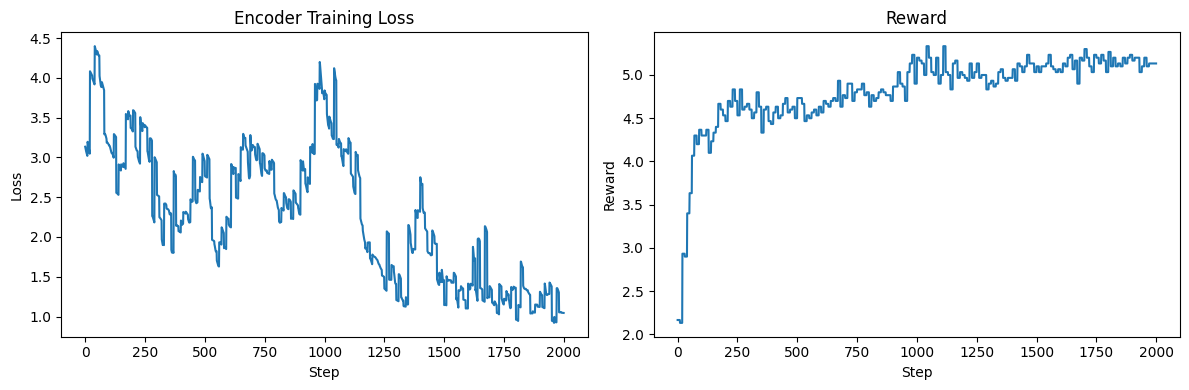

In [29]:
loss, reward = run_policy_gradient(prompts=prompt_test, vocab_size = vocab_size, deltas_mode='rewards', loss_mode='naive')

plot_run_and_reward(loss, reward)

### Naive Run, no Delta, KL

epoch: 100%|██████████████████████████████████████████████████████| 200/200 [00:00<00:00, 280.57it/s]


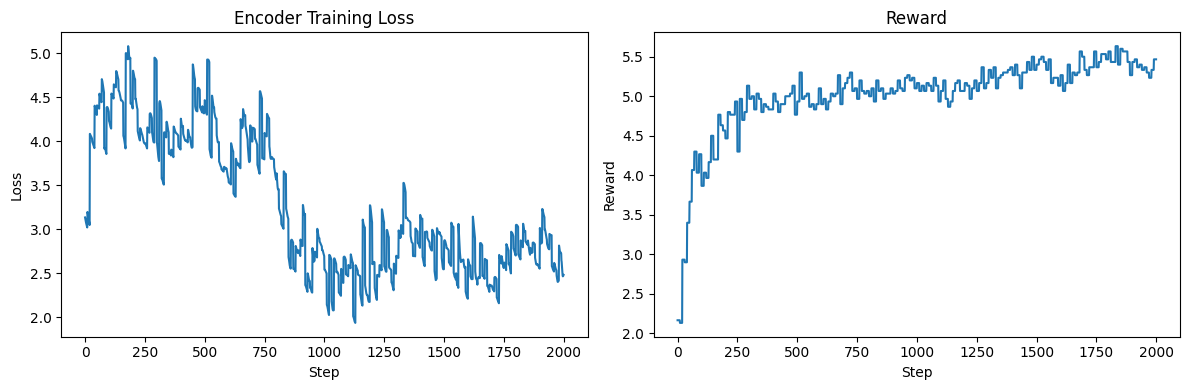

In [30]:
loss, reward = run_policy_gradient(prompts=prompt_test, vocab_size = vocab_size, deltas_mode='rewards', loss_mode='naive', kl_penalty=0.01)

plot_run_and_reward(loss, reward)

### Naive Run, Centered Rewards

epoch: 100%|██████████████████████████████████████████████████████| 200/200 [00:00<00:00, 312.90it/s]


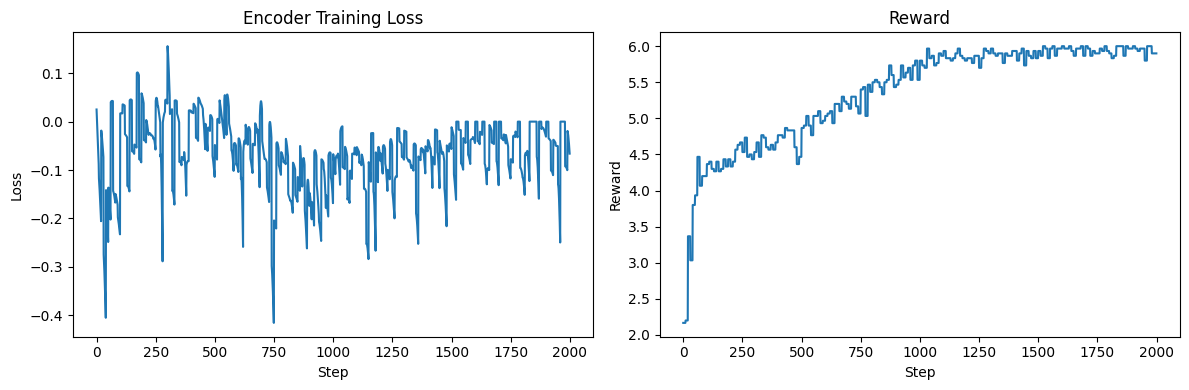

In [31]:
loss, reward  = run_policy_gradient(prompts=prompt_test, vocab_size = vocab_size, deltas_mode='centered', loss_mode='naive')

plot_run_and_reward(loss, reward)

### Naive Run, Normalized Rewards

epoch: 100%|██████████████████████████████████████████████████████| 200/200 [00:00<00:00, 312.30it/s]


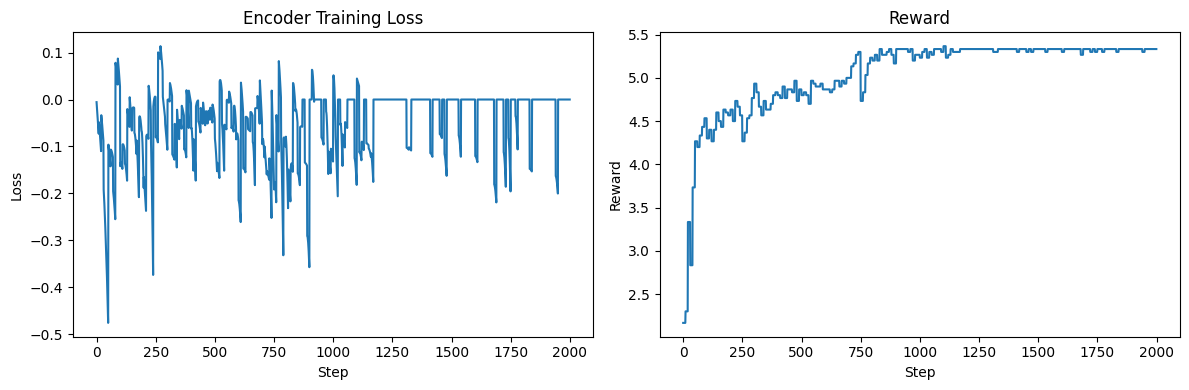

In [32]:
loss, reward = run_policy_gradient(prompts=prompt_test, vocab_size = vocab_size, deltas_mode='normalized', loss_mode='naive')

plot_run_and_reward(loss, reward)

### Naive Run, Max_Min Rewards

epoch: 100%|██████████████████████████████████████████████████████| 200/200 [00:00<00:00, 308.70it/s]


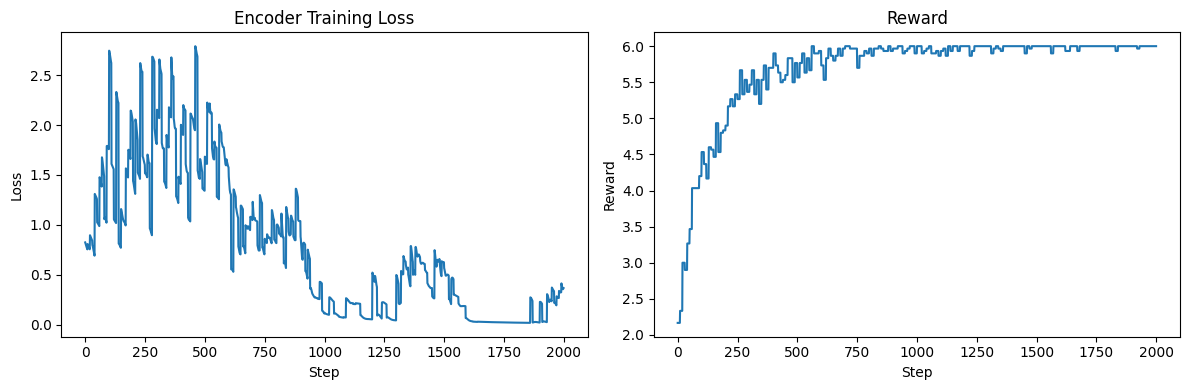

In [33]:
loss, reward = run_policy_gradient(prompts=prompt_test, vocab_size = vocab_size, deltas_mode='max_min', loss_mode='naive')

plot_run_and_reward(loss, reward)

### Naive Run, Max_Min Rewards, KL

epoch: 100%|██████████████████████████████████████████████████████| 200/200 [00:00<00:00, 278.33it/s]


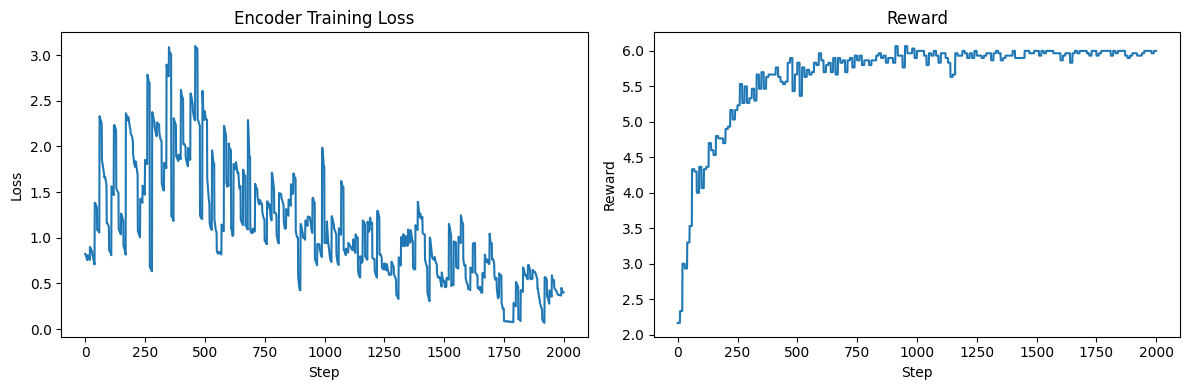

In [34]:
loss, reward = run_policy_gradient(prompts=prompt_test, vocab_size = vocab_size, deltas_mode='max_min', loss_mode='naive', kl_penalty=0.01)

plot_run_and_reward(loss, reward)

### Unclipped Run, Max_Min Rewards

epoch: 100%|██████████████████████████████████████████████████████| 200/200 [00:00<00:00, 300.98it/s]


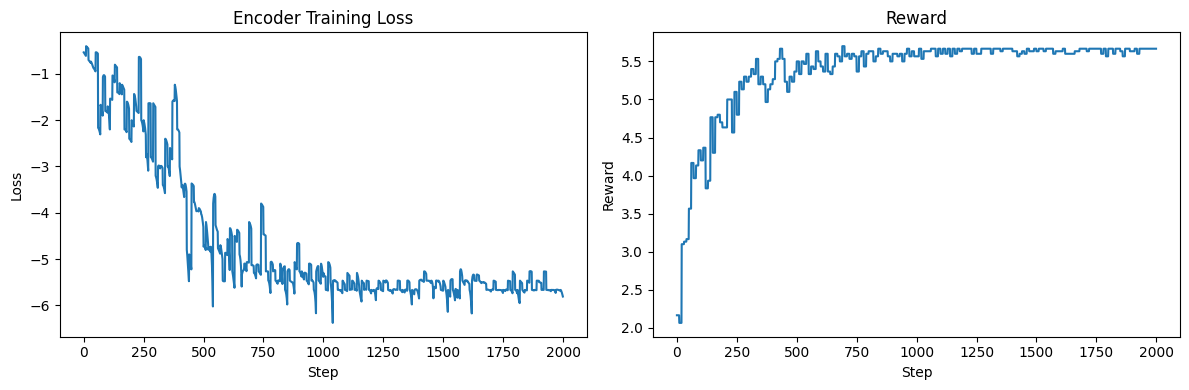

In [35]:
loss, reward = run_policy_gradient(prompts=prompt_test, vocab_size = vocab_size, deltas_mode='max_min', loss_mode='unclipped')

plot_run_and_reward(loss, reward)

### Clipped Run, Max_Min Rewards

epoch: 100%|██████████████████████████████████████████████████████| 200/200 [00:00<00:00, 280.07it/s]


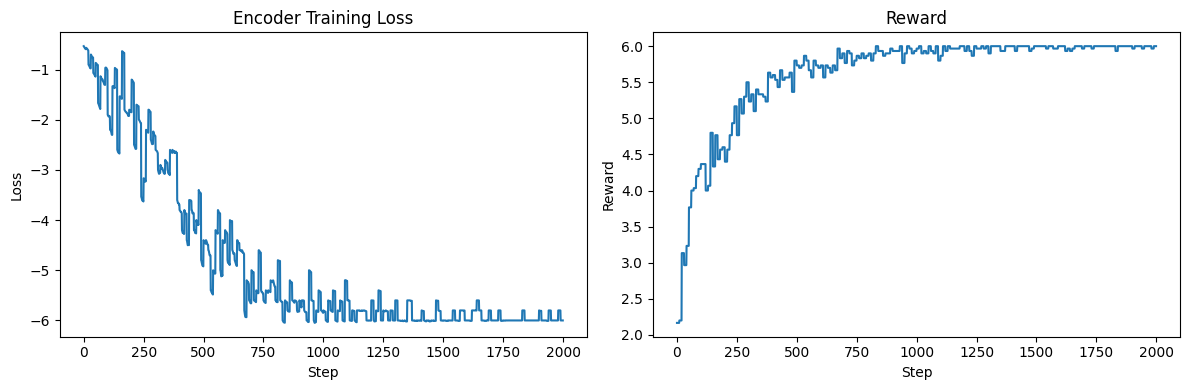

In [36]:
loss, reward = run_policy_gradient(prompts=prompt_test, vocab_size = vocab_size, deltas_mode='max_min', loss_mode='clipped')

plot_run_and_reward(loss, reward)

### Clipped Run, Max_Min Rewards, KL

epoch: 100%|██████████████████████████████████████████████████████| 200/200 [00:00<00:00, 257.27it/s]


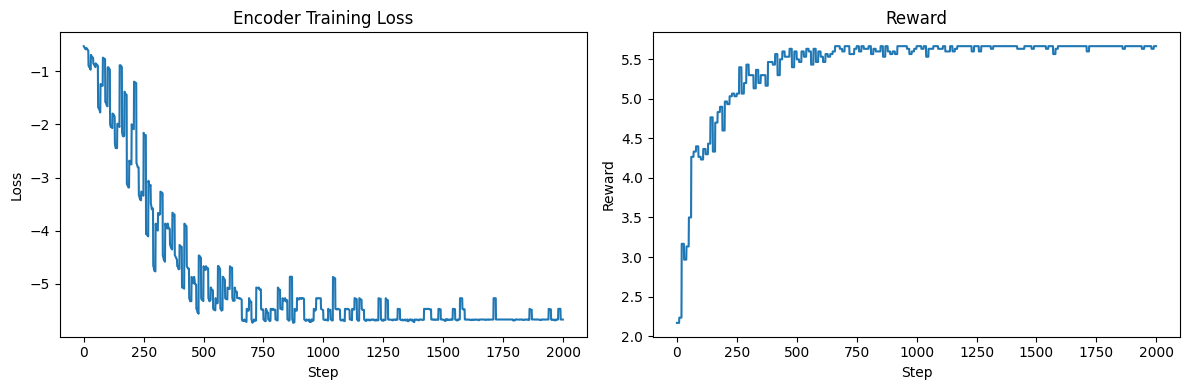

In [37]:
loss, reward = run_policy_gradient(prompts=prompt_test, vocab_size = vocab_size, deltas_mode='max_min', loss_mode='clipped', kl_penalty=0.01)

plot_run_and_reward(loss, reward)

### GRPO: Clipped Run, Normalized Rewards, KL

GRPO's defining moves are
1. group-relative advantages computed as mean/std-normalized rewards across the G samples per prompt. `normalized` deltas
2. the PPO-style clipped ratio surrogate. `clipped` loss
3. a KL penalty to a periodically-refreshed reference policy. `kl_penalty` over zero

epoch: 100%|██████████████████████████████████████████████████████| 200/200 [00:00<00:00, 258.74it/s]


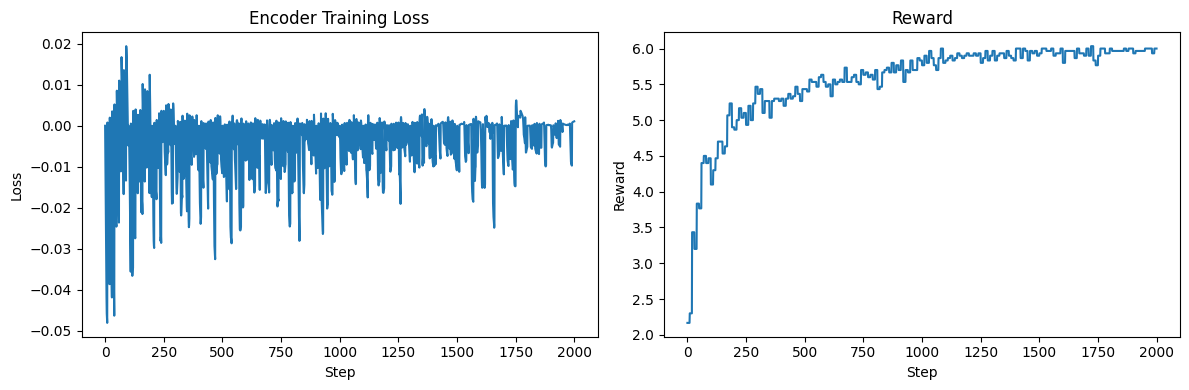

In [38]:
loss, reward = run_policy_gradient(prompts=prompt_test, vocab_size = vocab_size, deltas_mode='normalized', loss_mode='clipped', kl_penalty=0.01)

plot_run_and_reward(loss, reward)